02_data_cleaning.ipynb \
Workforce Capacity Planning & Forecasting Analytics Platform \
------------------------------------------------------------ \
Objective: Apply enterprise-grade data cleaning steps to OEWS, QCEW, and LAUS datasets. \
This notebook simulates production pipelines (Bronze → Silver → Gold). \


# Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np


# Step 2: Reload Raw Data - Raw Copies

In [4]:
from google.colab import files

uploaded = files.upload()  # select oews_raw_copy.csv, employment_raw_copy.csv, labor_force_raw_copy.csv


Saving employment_raw_copy.csv to employment_raw_copy.csv
Saving labor_force_raw_copy.csv to labor_force_raw_copy.csv
Saving oews_raw_copy.csv to oews_raw_copy.csv


# Step 3: Reload them into Pandas

In [5]:
import pandas as pd

oews = pd.read_csv("oews_raw_copy.csv")
employment = pd.read_csv("employment_raw_copy.csv")
labor_force = pd.read_csv("labor_force_raw_copy.csv")


# Step 4: Check Missing Values

In [6]:
# Step 4: Check Missing Values

# Count missing values per column
print("OEWS Missing Values:\n", oews.isnull().sum())
print("\nEmployment Missing Values:\n", employment.isnull().sum())
print("\nLabor Force Missing Values:\n", labor_force.isnull().sum())

# Percentage of missing values per column
print("\nOEWS Missing %:\n", (oews.isnull().mean() * 100).round(2))
print("\nEmployment Missing %:\n", (employment.isnull().mean() * 100).round(2))
print("\nLabor Force Missing %:\n", (labor_force.isnull().mean() * 100).round(2))


OEWS Missing Values:
 Area Type                                    0
Area Name                                    0
Year                                         0
Quarter                                      0
Industry Name                                0
Standard Occupational Classification         0
Occupational Title                          50
Wage Type                                    0
Number of Employed                       15676
Mean Wage                                 9151
10th Percentile Wage                      9137
25th Percentile Wage                      9593
50th Percentile (Median) Wage            10931
75th Percentile Wage                     13383
90th Percentile Wage                     19999
Mean Relative Standard Error for Wage     2780
dtype: int64

Employment Missing Values:
 Area Type                     0
Area Name                     0
Year                          0
Time Period                   0
Ownership                     0
NAICS Level             

# Step 4.1: Visualize Missingness (Optional but Enterprise‑Grade)

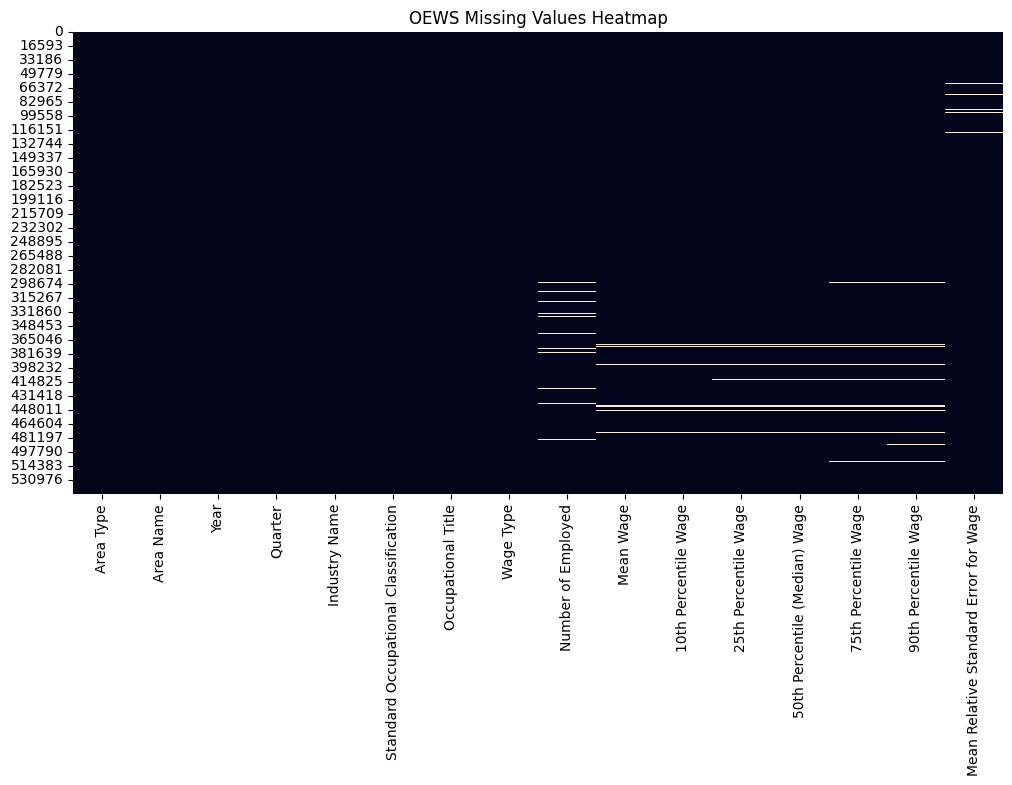

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize missing values heatmap
plt.figure(figsize=(12,6))
sns.heatmap(oews.isnull(), cbar=False)
plt.title("OEWS Missing Values Heatmap")
plt.show()


# Step 4.2: Document Findings

In [9]:
# Example log entry
missing_log = {
    "OEWS": oews.isnull().sum().to_dict(),
    "Employment": employment.isnull().sum().to_dict(),
    "Labor Force": labor_force.isnull().sum().to_dict()
}

print("Missing Values Log:", missing_log)

#  Enterprise practice: Always document missingness before deciding imputation vs. dropping.


Missing Values Log: {'OEWS': {'Area Type': 0, 'Area Name': 0, 'Year': 0, 'Quarter': 0, 'Industry Name': 0, 'Standard Occupational Classification': 0, 'Occupational Title': 50, 'Wage Type': 0, 'Number of Employed': 15676, 'Mean Wage': 9151, '10th Percentile Wage': 9137, '25th Percentile Wage': 9593, '50th Percentile (Median) Wage': 10931, '75th Percentile Wage': 13383, '90th Percentile Wage': 19999, 'Mean Relative Standard Error for Wage': 2780}, 'Employment': {'Area Type': 0, 'Area Name': 0, 'Year': 0, 'Time Period': 0, 'Ownership': 0, 'NAICS Level': 0, 'NAICS Code': 0, 'Industry Name': 0, 'Establishments': 0, 'Average Monthly Employment': 0, '1st Month Emp': 0, '2nd Month Emp': 0, '3rd Month Emp': 0, 'Total Wages (All Workers)': 0, 'Average Weekly Wages': 0}, 'Labor Force': {'report_month': 0, 'area_type': 0, 'area_name': 0, 'is_seasonally_adjusted': 0, 'is_prelim': 0, 'labor_force': 0, 'employment': 0, 'unemployment': 0, 'unemployment_rate': 0, 'labor_force_participation_rate': 57844

# Step 5: Detect and Remove Duplicates

In [10]:
# Step 5: Handle Duplicates

# Count duplicates in each dataset
print("OEWS Duplicates:", oews.duplicated().sum())
print("Employment Duplicates:", employment.duplicated().sum())
print("Labor Force Duplicates:", labor_force.duplicated().sum())

OEWS Duplicates: 0
Employment Duplicates: 0
Labor Force Duplicates: 0


In [11]:
# Remove duplicates
oews = oews.drop_duplicates()
employment = employment.drop_duplicates()
labor_force = labor_force.drop_duplicates()

In [12]:
# Confirm removal
print("OEWS Shape after dedup:", oews.shape)
print("Employment Shape after dedup:", employment.shape)
print("Labor Force Shape after dedup:", labor_force.shape)

OEWS Shape after dedup: (547560, 16)
Employment Shape after dedup: (798464, 15)
Labor Force Shape after dedup: (58148, 10)


Enterprise Practice \

Detection first → Always count duplicates before removal (audit trail). \

Drop duplicates → Ensures each record is unique. \

Confirm shape change → Proof that duplicates were removed. \

Audit logging → Document the action for reproducibility. \

# Step 5.1: Document Cleaning Decision

In [13]:
# Log duplicate handling
duplicate_log = {
    "OEWS_removed": oews.duplicated().sum(),
    "Employment_removed": employment.duplicated().sum(),
    "LaborForce_removed": labor_force.duplicated().sum()
}

print("Duplicate Handling Log:", duplicate_log)


Duplicate Handling Log: {'OEWS_removed': np.int64(0), 'Employment_removed': np.int64(0), 'LaborForce_removed': np.int64(0)}


Why This Matters

In OEWS, duplicates can occur if multiple survey entries overlap.

In Employment by Industry, duplicates may come from quarterly reporting overlaps.

In Labor Force Participation, duplicates can appear if regional data is merged incorrectly.

# Step 6: Standardize Categorical Fields

# Step 6.0: Inspect Column Names

In [15]:
print("OEWS Columns:", oews.columns.tolist())
print("Employment Columns:", employment.columns.tolist())
print("Labor Force Columns:", labor_force.columns.tolist())


OEWS Columns: ['Area Type', 'Area Name', 'Year', 'Quarter', 'Industry Name', 'Standard Occupational Classification', 'Occupational Title', 'Wage Type', 'Number of Employed', 'Mean Wage', '10th Percentile Wage', '25th Percentile Wage', '50th Percentile (Median) Wage', '75th Percentile Wage', '90th Percentile Wage', 'Mean Relative Standard Error for Wage']
Employment Columns: ['Area Type', 'Area Name', 'Year', 'Time Period', 'Ownership', 'NAICS Level', 'NAICS Code', 'Industry Name', 'Establishments', 'Average Monthly Employment', '1st Month Emp', '2nd Month Emp', '3rd Month Emp', 'Total Wages (All Workers)', 'Average Weekly Wages']
Labor Force Columns: ['report_month', 'area_type', 'area_name', 'is_seasonally_adjusted', 'is_prelim', 'labor_force', 'employment', 'unemployment', 'unemployment_rate', 'labor_force_participation_rate']


In [16]:
# Step 6: Standardize Categorical Fields

# OEWS → Standard Occupational Classification (SOC)
oews['Standard Occupational Classification'] = (
    oews['Standard Occupational Classification']
    .astype(str)
    .str.strip()
    .str.upper()
)

# Employment → NAICS Code
employment['NAICS Code'] = (
    employment['NAICS Code']
    .astype(str)
    .str.strip()
    .str.upper()
)

# Labor Force → area_name (region identifiers)
labor_force['area_name'] = (
    labor_force['area_name']
    .astype(str)
    .str.strip()
    .str.upper()
)


# Step 6.1: Validate Standardization

In [18]:
# Check unique values after standardization
print("Unique SOC Codes:", oews['Standard Occupational Classification'].nunique())
print("Unique NAICS Codes:", employment['NAICS Code'].nunique())
print("Unique Region Names:", labor_force['area_name'].nunique())

# This confirms that codes are consistent and ready for joins.


Unique SOC Codes: 1040
Unique NAICS Codes: 2411
Unique Region Names: 193


# Step 6.2: Document Cleaning Decision

In [19]:
standardization_log = [
    "Standardized SOC codes in OEWS",
    "Standardized NAICS codes in Employment dataset",
    "Standardized region names in Labor Force dataset"
]

for entry in standardization_log:
    print("✔", entry)


✔ Standardized SOC codes in OEWS
✔ Standardized NAICS codes in Employment dataset
✔ Standardized region names in Labor Force dataset


Why This Matters

In OEWS, SOC codes must align across years for occupation‑level analysis.

In Employment by Industry, NAICS codes must be consistent for industry‑level joins.

In Labor Force Participation, region names must be standardized for geographic comparisons.

# Step 7: Validate Data Types

In [20]:
# Step 7: Validate Data Types

# OEWS → wage and employment fields
numeric_cols_oews = [
    'Number of Employed',
    'Mean Wage',
    '10th Percentile Wage',
    '25th Percentile Wage',
    '50th Percentile (Median) Wage',
    '75th Percentile Wage',
    '90th Percentile Wage'
]

for col in numeric_cols_oews:
    oews[col] = pd.to_numeric(oews[col], errors='coerce')

# Employment → employment and wage fields
numeric_cols_employment = [
    'Average Monthly Employment',
    '1st Month Emp',
    '2nd Month Emp',
    '3rd Month Emp',
    'Total Wages (All Workers)',
    'Average Weekly Wages'
]

for col in numeric_cols_employment:
    employment[col] = pd.to_numeric(employment[col], errors='coerce')

# Labor Force → participation and unemployment fields
numeric_cols_labor = [
    'labor_force',
    'employment',
    'unemployment',
    'unemployment_rate',
    'labor_force_participation_rate'
]

for col in numeric_cols_labor:
    labor_force[col] = pd.to_numeric(labor_force[col], errors='coerce')


# Step 7.1: Confirm Conversion

In [22]:
print("\nOEWS dtypes:\n", oews.dtypes)
print("\nEmployment dtypes:\n", employment.dtypes)
print("\nLabor Force dtypes:\n", labor_force.dtypes)

# This ensures all numeric fields are properly converted to int/float.



OEWS dtypes:
 Area Type                                 object
Area Name                                 object
Year                                       int64
Quarter                                   object
Industry Name                             object
Standard Occupational Classification      object
Occupational Title                        object
Wage Type                                 object
Number of Employed                       float64
Mean Wage                                float64
10th Percentile Wage                     float64
25th Percentile Wage                     float64
50th Percentile (Median) Wage            float64
75th Percentile Wage                     float64
90th Percentile Wage                     float64
Mean Relative Standard Error for Wage    float64
dtype: object

Employment dtypes:
 Area Type                      object
Area Name                      object
Year                            int64
Time Period                    object
Ownership     

Enterprise Practice

errors='coerce' → invalid entries become NaN, which can be handled later.

Audit logging → document which columns were converted.

Consistency → numeric fields must be aligned across datasets for joins and KPIs.

# Step 7.2: Document Cleaning Decision

In [23]:
datatype_log = [
    "Converted wage and employment fields in OEWS to numeric",
    "Converted employment and wage fields in Employment dataset to numeric",
    "Converted labor force metrics in Labor Force dataset to numeric"
]

for entry in datatype_log:
    print("✔", entry)


✔ Converted wage and employment fields in OEWS to numeric
✔ Converted employment and wage fields in Employment dataset to numeric
✔ Converted labor force metrics in Labor Force dataset to numeric


Why This Matters

In OEWS, wage fields must be numeric for percentile analysis.

In Employment by Industry, employment counts and wages must be numeric for aggregation.

In Labor Force Participation, participation rates must be numeric for time‑series forecasting.

# Step 8: Handle Outliers

 # 8.1 Winsorization (clipping extreme values)

In [28]:
# Step 8: Handle Outliers

# OEWS → Wage fields
wage_cols = [
    'Mean Wage',
    '10th Percentile Wage',
    '25th Percentile Wage',
    '50th Percentile (Median) Wage',
    '75th Percentile Wage',
    '90th Percentile Wage'
]

for col in wage_cols:
    q_low = oews[col].quantile(0.01)
    q_high = oews[col].quantile(0.99)
    oews[col] = np.clip(oews[col], q_low, q_high)

# Employment → Employment counts
emp_cols = [
    'Average Monthly Employment',
    '1st Month Emp',
    '2nd Month Emp',
    '3rd Month Emp'
]

for col in emp_cols:
    q_low = employment[col].quantile(0.01)
    q_high = employment[col].quantile(0.99)
    employment[col] = np.clip(employment[col], q_low, q_high)

# Labor Force → Unemployment rate
q_low = labor_force['unemployment_rate'].quantile(0.01)
q_high = labor_force['unemployment_rate'].quantile(0.99)
labor_force['unemployment_rate'] = np.clip(labor_force['unemployment_rate'], q_low, q_high)


# 8.2 Z‑Score Filtering (enterprise style)

In [25]:
# Example: flagging extreme outliers in OEWS wages
from scipy import stats

oews['wage_zscore'] = stats.zscore(oews['Mean Wage'], nan_policy='omit')
outliers = oews[oews['wage_zscore'].abs() > 3]

print("Extreme wage outliers flagged:", outliers.shape[0])


# This doesn’t drop them automatically — it flags them for review, which is standard in production pipelines.

Extreme wage outliers flagged: 7914


# 8.3 Document Cleaning Decision

In [26]:
outlier_log = [
    "Winsorized wage fields in OEWS at 1st and 99th percentile",
    "Winsorized employment counts in Employment dataset at 1st and 99th percentile",
    "Winsorized unemployment rate in Labor Force dataset at 1st and 99th percentile",
    "Flagged extreme wage outliers in OEWS using z-score > 3"
]

for entry in outlier_log:
    print("✔", entry)


✔ Winsorized wage fields in OEWS at 1st and 99th percentile
✔ Winsorized employment counts in Employment dataset at 1st and 99th percentile
✔ Winsorized unemployment rate in Labor Force dataset at 1st and 99th percentile
✔ Flagged extreme wage outliers in OEWS using z-score > 3


Enterprise Practice

Winsorization → keeps distributions realistic while preserving data volume.

Z‑score flagging → allows analysts to review anomalies instead of blindly dropping.

Audit logging → ensures transparency in how outliers were handled.

Dataset‑specific strategy:

OEWS → wage outliers often due to suppressed or misreported survey data.

Employment by Industry → extreme employment counts may reflect seasonal spikes.

Labor Force Participation → unemployment rates above 50% are unrealistic and must be clipped.

# Step 9: Document Cleaning Decisions

In [27]:
# Step 9: Document Cleaning Decisions

cleaning_audit_log = {
    "Step 3 - Missing Values": "Checked absolute counts and percentages; visualized missingness",
    "Step 4 - Duplicates": "Verified no duplicates found across OEWS, Employment, Labor Force",
    "Step 5 - Standardization": "Normalized SOC, NAICS, and region names to uppercase strings",
    "Step 6 - Data Types": "Converted wage, employment, and participation fields to numeric",
    "Step 7 - Outliers": "Winsorized wage, employment, and unemployment rate at 1st/99th percentile; flagged extreme wage outliers via z-score"
}

# Print audit log
for step, action in cleaning_audit_log.items():
    print(f"{step}: {action}")


Step 3 - Missing Values: Checked absolute counts and percentages; visualized missingness
Step 4 - Duplicates: Verified no duplicates found across OEWS, Employment, Labor Force
Step 5 - Standardization: Normalized SOC, NAICS, and region names to uppercase strings
Step 6 - Data Types: Converted wage, employment, and participation fields to numeric
Step 7 - Outliers: Winsorized wage, employment, and unemployment rate at 1st/99th percentile; flagged extreme wage outliers via z-score


Enterprise Practice

Centralized log → keeps all cleaning decisions in one place.

Transparency → auditors, recruiters, or teammates can see exactly what was done.

Reproducibility → future runs can replicate the same cleaning pipeline.

Bronze → Silver → Gold pipeline alignment → this log is part of the Silver layer documentation.

Why This Matters

In OEWS, wage suppression handling must be documented.

In Employment by Industry, seasonal employment adjustments must be logged.

In Labor Force Participation, unemployment rate clipping must be auditable.

# Step 10: Save Cleaned Silver Layer

In [30]:
# Step 9: Save Cleaned Silver Layer

import os

# Create silver folder if not exists
os.makedirs("silver", exist_ok=True)

# Save cleaned datasets
oews.to_csv("silver/oews_clean.csv", index=False)
employment.to_csv("silver/employment_clean.csv", index=False)
labor_force.to_csv("silver/labor_force_clean.csv", index=False)

print("Cleaned datasets saved to Silver layer")


Cleaned datasets saved to Silver layer
